In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs, make_classification, make_gaussian_quantiles
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn import svm
from sklearn.model_selection import GridSearchCV
import seaborn as sns

1. Возьмите набор данных для многоклассовй классификации.


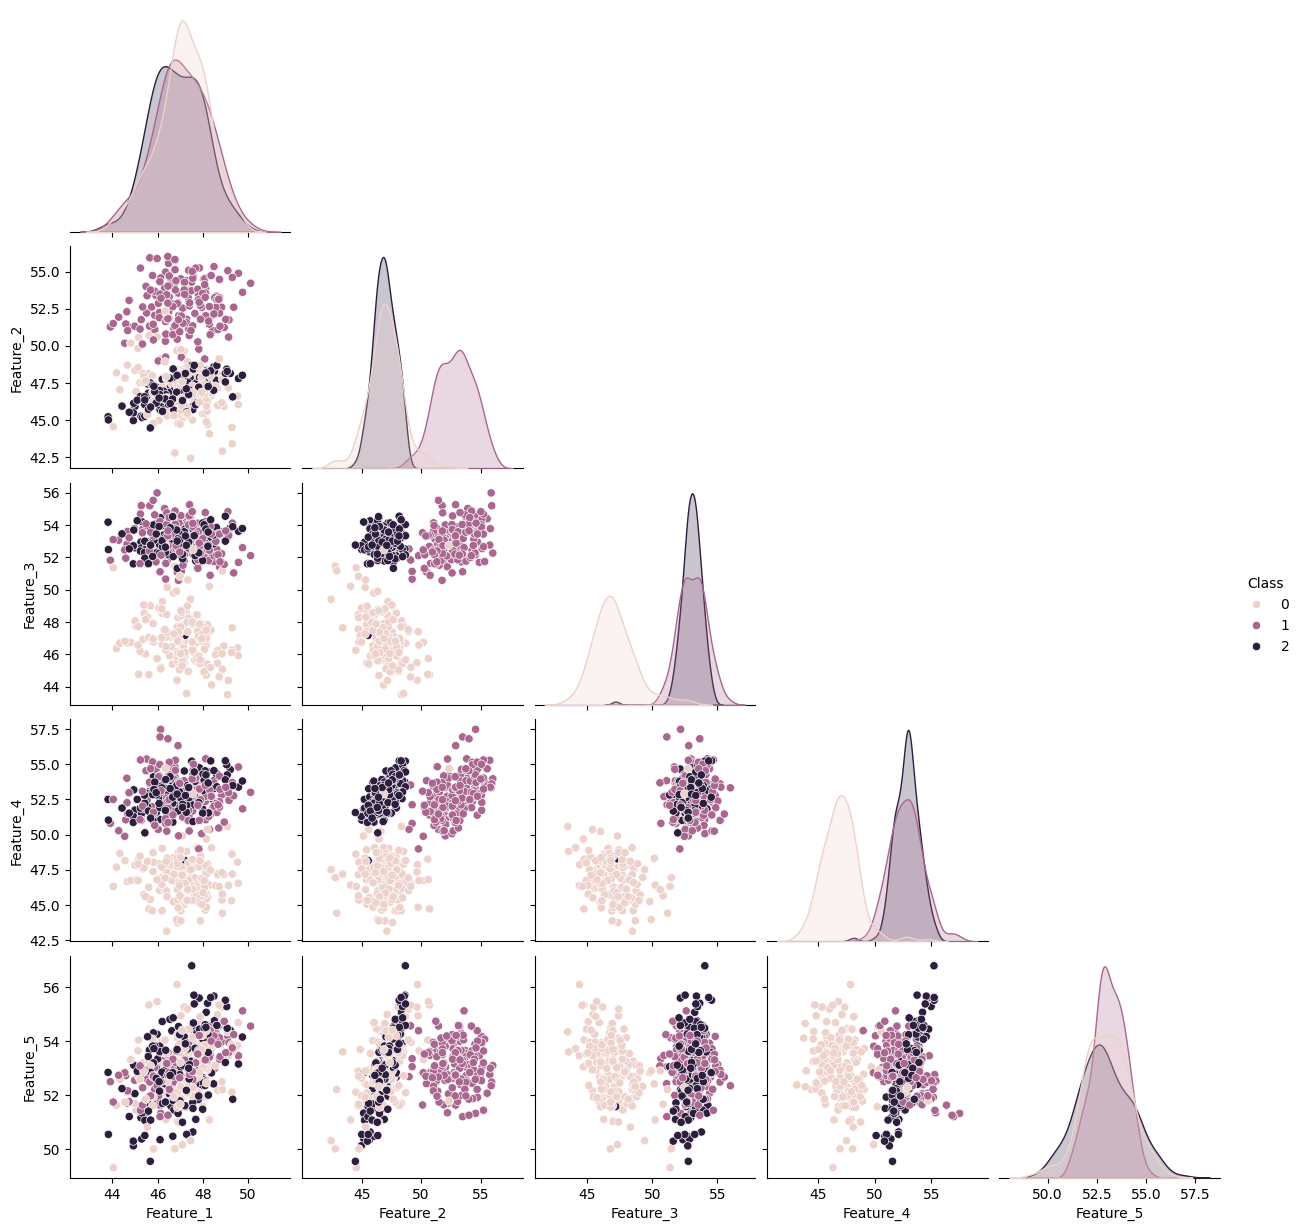

In [24]:
# plt.figure(figsize=(8, 8))
# plt.subplots_adjust(bottom=0.05, top=0.9, left=0.05, right=0.95)

# plt.subplot(324)
n_classes = 3
n_features = 5
# X, Y = make_classification(n_features=4, n_redundant=0, n_informative=2, n_clusters_per_class=1, n_classes=4)
X, Y = make_classification(n_features=n_features, n_redundant=0, n_informative=5, n_classes=n_classes, n_clusters_per_class=1, shift=50, n_samples=500, class_sep=3.)
# plt.scatter(X[:, 0], X[:, 1], marker="o", c=Y, s=25, edgecolor="k")

df = pd.DataFrame(X, columns=[f'Feature_{i+1}' for i in range(X.shape[1])])
df['Class'] = Y
sns.pairplot(df, hue='Class', diag_kind='kde', corner=True)

2. Выберете 2-3 разные модели по типу дерева или байесовского классификатора.  


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)
sk_nb_clf = GaussianNB()
sk_nb_clf.fit(X_train, y_train)
sk_nb_clf_pred_res = sk_nb_clf.predict(X_test)
sk_nb_clf_accuracy = accuracy_score(y_test, sk_nb_clf_pred_res)

print(f'sk Naive Bayes classifier accucacy: {sk_nb_clf_accuracy}')
# print(sk_nb_clf_pred_res)

sk Naive Bayes classifier accucacy: 0.97


In [26]:
clf = svm.SVC(kernel="linear")
clf = clf.fit(X_train, y_train)
clf.fit(X_train, y_train)
clf_pred_res = clf.predict(X_test)
clf_accuracy = accuracy_score(y_test, clf_pred_res)

print(f'accuracy: {clf_accuracy}')


accuracy: 0.98


3. Используйте GridSearchCV для определения лучших гиперпарамеров (для оценки модели используйте кросс валидацию)

In [ ]:
from sklearn.naive_bayes import GaussianNB
import random

priors_array = [[0.9, 0.05, 0.05], [0.4, 0.3, 0.3], [0.05, 0.9, 0.05], [0.3, 0.3, 0.4], [0.05, 0.05, 0.9]]
param_grid_bayes = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.2, 0.5, 0.7, 1, 2, 3, 4, 5, 10, 100],
    'priors': priors_array
}

grid_search_bayes = GridSearchCV(estimator = sk_nb_clf, param_grid = param_grid_bayes, cv=5, scoring='accuracy')
grid_search_bayes.fit(X_train, y_train)

print("Best parameters for Bayes:", grid_search_bayes.best_params_)
print("Best accuracy:", grid_search_bayes.best_score_)


Best parameters for Bayes: {'priors': [0.05, 0.9, 0.05], 'var_smoothing': 1e-09}
Best accuracy: 0.9925


In [ ]:
# from sklearn.model_selection import cross_val_score

# model_bayes = GaussianNB(var_smoothing = 1e-09)

# cv_scores = cross_val_score(model_bayes, X_train, y_train, cv=5, scoring='accuracy')
# average_score = cv_scores.mean()

# # print("Cross-Validation Scores:", cv_scores)
# print("Average Score:", average_score)

In [29]:
from sklearn.model_selection import GridSearchCV
param_grid_svc = {
    'C': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 3, 4, 5, 10, 50, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_search_svc = GridSearchCV(svm.SVC(), param_grid_svc, cv=5)
grid_search_svc.fit(X_train, y_train)
print("Best parameters for SVM:", grid_search_svc.best_params_)
print("Best accuracy:", grid_search_svc.best_score_)


Best parameters for SVM: {'C': 0.05, 'gamma': 'scale', 'kernel': 'linear'}
Best accuracy: 0.9925


In [ ]:
# from sklearn.model_selection import cross_val_score

# model = svm.SVC(C = 1, kernel="rbf", gamma = "auto")

# cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
# average_score = cv_scores.mean()

# # print("Cross-Validation Scores:", cv_scores)
# print("Average Score:", average_score)

4. Визуализируйте полученные результаты, сделайте сравнительные таблицы и графики.


Bayes Results:
     param_var_smoothing       param_priors  mean_test_score
0          1.000000e-09  [0.9, 0.05, 0.05]           0.9875
1          1.000000e-08  [0.9, 0.05, 0.05]           0.9875
2          1.000000e-07  [0.9, 0.05, 0.05]           0.9875
3          1.000000e-06  [0.9, 0.05, 0.05]           0.9875
4          1.000000e-05  [0.9, 0.05, 0.05]           0.9875
..                  ...                ...              ...
90         3.000000e+00  [0.05, 0.05, 0.9]           0.3275
91         4.000000e+00  [0.05, 0.05, 0.9]           0.3275
92         5.000000e+00  [0.05, 0.05, 0.9]           0.3275
93         1.000000e+01  [0.05, 0.05, 0.9]           0.3275
94         1.000000e+02  [0.05, 0.05, 0.9]           0.3275

[95 rows x 3 columns]
Bayes Results:
     param_var_smoothing       param_priors  mean_test_score
0          1.000000e-09  [0.9, 0.05, 0.05]           0.9875
1          1.000000e-08  [0.9, 0.05, 0.05]           0.9875
2          1.000000e-07  [0.9, 0.05, 0.05]   

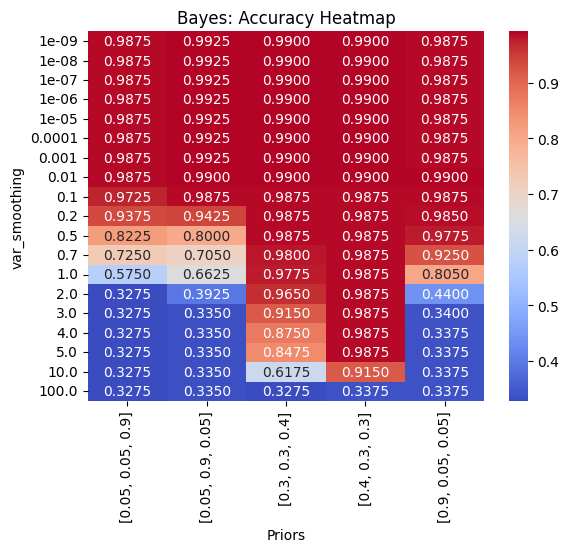

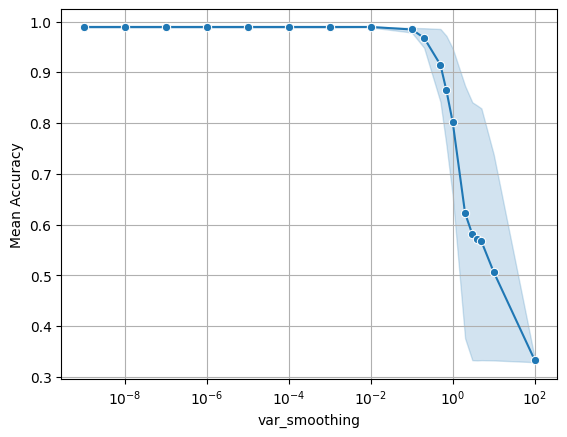

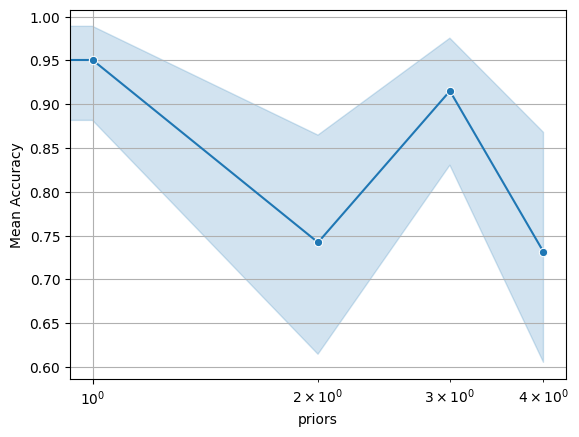

SVM Results:
     param_C param_kernel param_gamma  mean_test_score
0     0.001       linear       scale           0.9875
1     0.001          rbf       scale           0.4025
2     0.001       linear        auto           0.9875
3     0.001          rbf        auto           0.4000
4     0.005       linear       scale           0.9900
5     0.005          rbf       scale           0.4025
6     0.005       linear        auto           0.9900
7     0.005          rbf        auto           0.4000
8     0.010       linear       scale           0.9900
9     0.010          rbf       scale           0.7800
10    0.010       linear        auto           0.9900
11    0.010          rbf        auto           0.4000
12    0.050       linear       scale           0.9925
13    0.050          rbf       scale           0.9875
14    0.050       linear        auto           0.9925
15    0.050          rbf        auto           0.9900
16    0.100       linear       scale           0.9925
17    0.100   

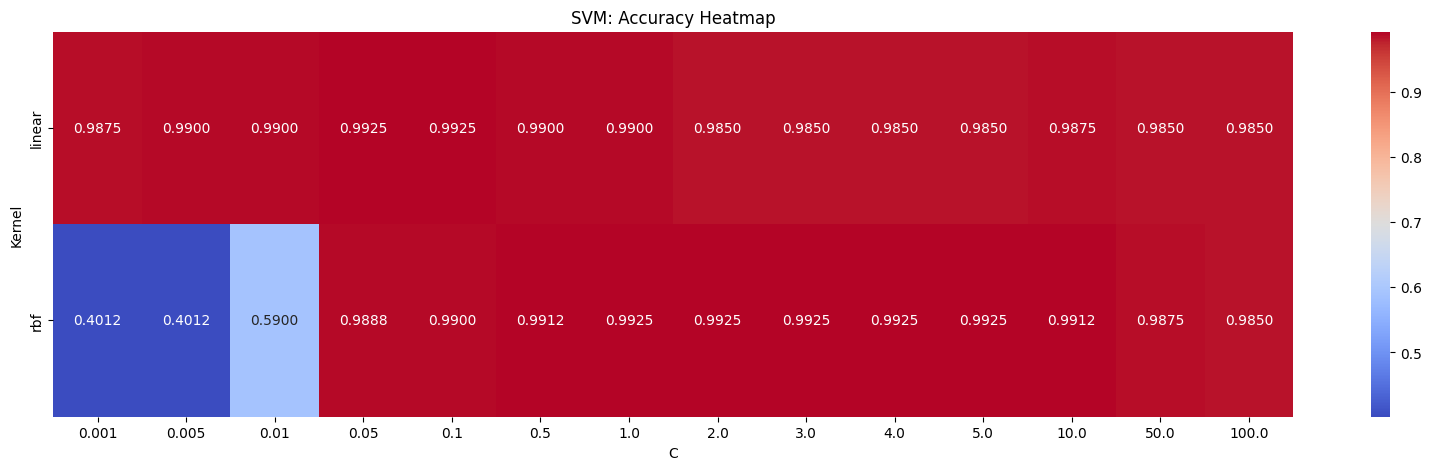

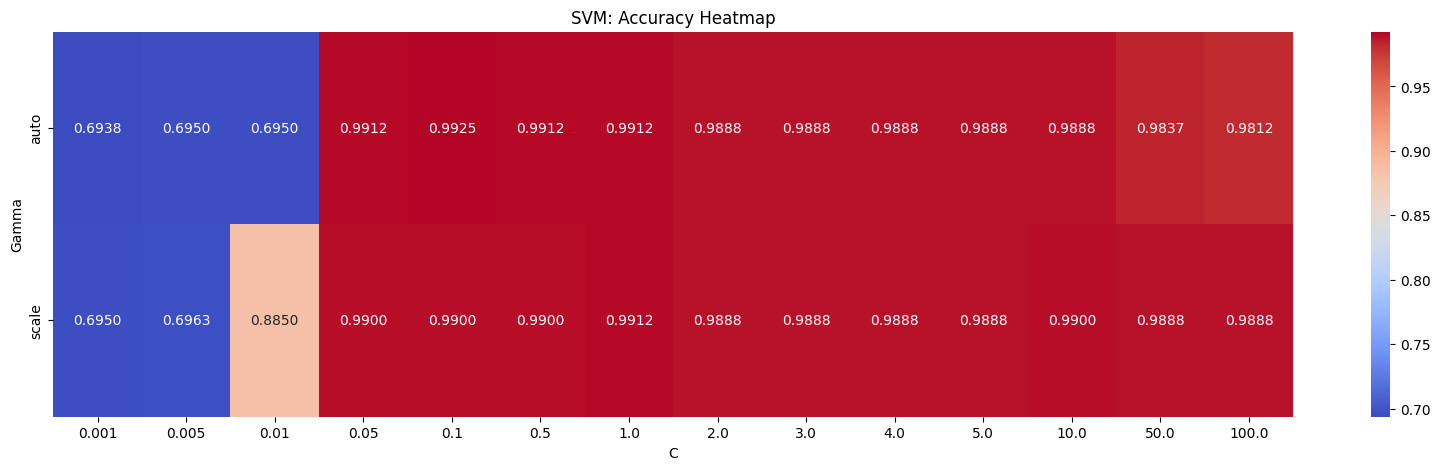

In [ ]:
import seaborn as sns

priors_str = ''.join(str(priors_array) for x in priors_array)
bayes_results = pd.DataFrame(grid_search_bayes.cv_results_)
print("Bayes Results:\n", bayes_results[['param_var_smoothing', 'param_priors', 'mean_test_score']])

# for i in bayes_results['param_priors']:
#     for j in range(len(priors_array)):
#         if (i == priors_array[j]):
#             i = priors_str[j]
# for i in range(len(priors_array)):
#     bayes_results['param_priors'] = bayes_results['param_priors'].replace(priors_array[i], priors_str[i])
bayes_results['param_priors'] = bayes_results['param_priors'].apply(str)

print("Bayes Results:\n", bayes_results[['param_var_smoothing', 'param_priors', 'mean_test_score']])
# print("Bayes Results:\n", bayes_results)
bayes_pivot = bayes_results.pivot_table(
    values='mean_test_score',
    index='param_var_smoothing',
    columns='param_priors'
)
# plt.figure(figsize=(8, 5))
sns.heatmap(bayes_pivot, annot=True, fmt='.4f', cmap='coolwarm')
plt.title('Bayes: Accuracy Heatmap')
plt.xlabel('Priors')
plt.ylabel('var_smoothing')
plt.show()

# plt.figure(figsize=(8, 5))
sns.lineplot(data=bayes_results, x='param_var_smoothing', y='mean_test_score', marker='o')
plt.xscale('log')
plt.xlabel('var_smoothing')
plt.ylabel('Mean Accuracy')
plt.grid(True)
plt.show()

# plt.figure(figsize=(8, 5))
sns.lineplot(data=bayes_results, x='param_priors', y='mean_test_score', marker='o')
plt.xscale('log')
plt.xlabel('priors')
plt.ylabel('Mean Accuracy')
plt.grid(True)
plt.show()

svc_results = pd.DataFrame(grid_search_svc.cv_results_)
print("SVM Results:\n", svc_results[['param_C', 'param_kernel', 'param_gamma', 'mean_test_score']])

svc_pivot = svc_results.pivot_table(
    values='mean_test_score',
    index='param_kernel',
    columns='param_C'
)
plt.figure(figsize=(20, 5))
sns.heatmap(svc_pivot, annot=True, fmt='.4f', cmap='coolwarm')
plt.title('SVM: Accuracy Heatmap')
plt.xlabel('C')
plt.ylabel('Kernel')
plt.show()

svc_pivot = svc_results.pivot_table(
    values='mean_test_score',
    index='param_gamma',
    columns='param_C'
)
plt.figure(figsize=(20, 5))
sns.heatmap(svc_pivot, annot=True, fmt='.4f', cmap='coolwarm')
plt.title('SVM: Accuracy Heatmap')
plt.xlabel('C')
plt.ylabel('Gamma')
plt.show()

# sns.pairplot(svc_results, hue='param_kernel', diag_kind='kde', corner=True)

In [32]:
comparison_table = pd.DataFrame({
    'Model': ['Naive Bayes',  'SVM (RBF)'],
    'Best Hyperparameters': [
        grid_search_bayes.best_params_,
        {'C': grid_search_svc.best_params_['C'], 'kernel': 'rbf', 'gamma': grid_search_svc.best_params_['gamma']}
    ],
    'Best Accuracy': [
        grid_search_bayes.best_score_,
        grid_search_svc.cv_results_['mean_test_score'][svc_results['param_kernel'] == 'rbf'].max()
    ],
    'Hyperparameters':[
    '1e-09',
    {'C': 1, 'kernel': 'linear', 'gamma':'scale'}
    ],
    'Accuracy': [
        '0.8',
        '0.9'
    ]
})
print("Comparison Table:\n", comparison_table)


Comparison Table:
          Model                               Best Hyperparameters  \
0  Naive Bayes  {'priors': [0.05, 0.9, 0.05], 'var_smoothing':...   
1    SVM (RBF)     {'C': 0.05, 'kernel': 'rbf', 'gamma': 'scale'}   

   Best Accuracy                                 Hyperparameters Accuracy  
0         0.9925                                           1e-09      0.8  
1         0.9925  {'C': 1, 'kernel': 'linear', 'gamma': 'scale'}      0.9  


5. Посмотрите какие фреймворки AutoML существуют. Продемонстрируйте работу одного из них на ваш выбор (набор данных тот же)

In [ ]:
from tpot import TPOTClassifier

tpot = TPOTClassifier(
    generations=5,
    population_size=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    verbosity=2
)

tpot.fit(X_train, y_train)

tpot_accuracy = tpot.score(X_test, y_test)
print("TPOT Test Accuracy:", tpot_accuracy)

tpot.export('best_pipeline.py')


ModuleNotFoundError: No module named 'tpot'